In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('mobile_dataset.csv')
df.head(5)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
#Univariant selection

In [3]:
x = df.iloc[:,:-1]
y = df['price_range']

In [4]:
x.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [5]:
y.head()

0    1
1    2
2    2
3    2
4    1
Name: price_range, dtype: int64

In [6]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import chi2


In [7]:
ordered_rank_features = SelectKBest(score_func=chi2, k =20)
ordered_features = ordered_rank_features.fit(x,y)

In [8]:
dfscore = pd.DataFrame(ordered_features.scores_,columns=['Score'])
dfcolumns = pd.DataFrame(x.columns )

In [9]:
features_rank = pd.concat([dfcolumns,dfscore],axis=1)

In [11]:
features_rank.columns = ['Features','Score']
features_rank.nlargest(10,'Score')


# It is use for kai square analiysis and hytpothissis tesing  

,Features,Score
13,ram,931267.519053
11,px_height,17363.569536
0,battery_power,14129.866576
12,px_width,9810.586750
8,mobile_wt,95.972863
6,int_memory,89.839124
15,sc_w,16.480319
16,talk_time,13.236400
4,fc,10.135166
14,sc_h,9.614878


In [12]:
from sklearn.feature_selection import VarianceThreshold

In [17]:
va  =VarianceThreshold(threshold=0)

In [18]:
va.fit(x)

VarianceThreshold(threshold=0)

In [19]:
va.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [20]:
cor = x.corr()
cor

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,0.031441,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,-0.009952,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,-0.005245,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,-0.017143,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,0.644595,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,-0.005598,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,-0.033273,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,0.026282,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,0.018844,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,-0.001193,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964


<Axes: >

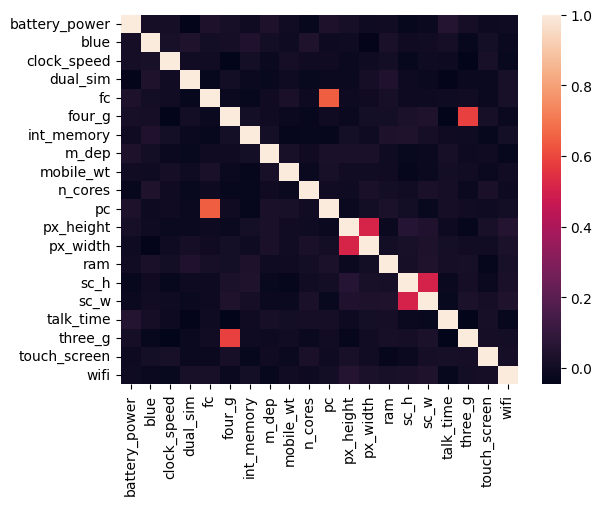

In [26]:
import seaborn as sn
import matplotlib as plt

# plt.figure(figsize=(12,10))
# sn.heatmap(cor, annot=True)
sn.heatmap(cor)

In [56]:
def correlation(deta,threshold):
    col_corr = set()
    corr_matrix = deta.corr()
    # print("it is run" , len(corr_matrix.columns))
    for i in range (len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                print(colname)
                col_corr.add(colname)
    return col_corr

In [59]:
val = correlation(x,0.1)

pc
px_width
sc_w
three_g


In [49]:
xx = x.corr()
xx.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')

In [60]:
x.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [63]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [64]:

x.drop(list(val),axis=1)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,px_height,ram,sc_h,talk_time,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,20,2549,9,19,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,905,2631,17,7,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,1263,2603,11,9,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,1216,2769,16,11,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,1208,1411,8,15,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,1222,668,13,19,1,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,915,2032,11,16,1,1
1997,1911,0,0.9,1,1,1,36,0.7,108,8,868,3057,9,5,1,0
1998,1512,0,0.9,0,4,1,46,0.1,145,5,336,869,18,19,1,1


In [65]:
x['blue'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       1
2       1
3       1
4       1
       ..
1995    1
1996    1
1997    0
1998    0
1999    1
Name: blue, Length: 2000, dtype: int64>

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(x,y)
mutual_info

array([0.0269186 , 0.01428106, 0.        , 0.01606632, 0.02035203,
       0.        , 0.00359469, 0.00200061, 0.01236785, 0.        ,
       0.        , 0.01998334, 0.02168429, 0.84699495, 0.        ,
       0.        , 0.        , 0.00603231, 0.02098073, 0.        ])

In [67]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

ram              0.846995
battery_power    0.026919
px_width         0.021684
touch_screen     0.020981
fc               0.020352
px_height        0.019983
dual_sim         0.016066
blue             0.014281
mobile_wt        0.012368
three_g          0.006032
int_memory       0.003595
m_dep            0.002001
sc_w             0.000000
talk_time        0.000000
pc               0.000000
sc_h             0.000000
n_cores          0.000000
four_g           0.000000
clock_speed      0.000000
wifi             0.000000
dtype: float64

<Axes: >

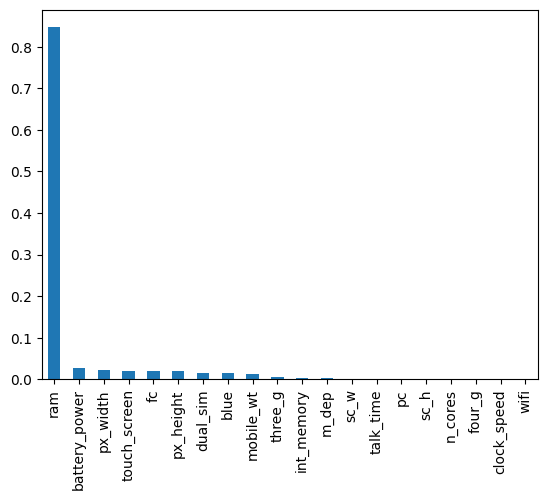

In [ ]:
mutual_info.sort_values(ascending=False).plot.bar()

In [ ]:
from sklearn.feature_selection import SelectKBest
select_five_cols = SelectKBest(mutual_info_classif, k=5)
select_five_cols.fit(x,y)
x.columns[select_five_cols.get_support()] 

Index(['battery_power', 'm_dep', 'px_height', 'px_width', 'ram'], dtype='object')

In [73]:
from sklearn.feature_selection import mutual_info_regression

mreg = mutual_info_regression(x,y)
# mm = mreg.fit(x,y)

mreg

array([0.03294807, 0.01609335, 0.00971935, 0.        , 0.00355509,
       0.01495847, 0.00501358, 0.        , 0.01002936, 0.01949247,
       0.        , 0.02195956, 0.02857491, 0.84803616, 0.        ,
       0.        , 0.        , 0.02281384, 0.0290133 , 0.        ])

In [75]:
mutual_info = pd.Series(mutual_info)

mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

ram              0.846995
battery_power    0.026919
px_width         0.021684
touch_screen     0.020981
fc               0.020352
px_height        0.019983
dual_sim         0.016066
blue             0.014281
mobile_wt        0.012368
three_g          0.006032
int_memory       0.003595
m_dep            0.002001
sc_w             0.000000
talk_time        0.000000
pc               0.000000
sc_h             0.000000
n_cores          0.000000
four_g           0.000000
clock_speed      0.000000
wifi             0.000000
dtype: float64

In [78]:
# from sklearn.model_selection import SelectKBest

select_col = SelectKBest(mutual_info_regression,k=5)
select_col.fit(x,y)
x.columns[select_col.get_support()]

Index(['battery_power', 'px_height', 'px_width', 'ram', 'touch_screen'], dtype='object')

In [80]:
from sklearn.feature_selection import chi2

pp = chi2(x,y)

In [83]:
ser = pd.Series(pp[1])
ser.index = x.columns
ser.sort_values(ascending=False)

three_g          9.547485e-01
wifi             9.356422e-01
dual_sim         8.892979e-01
clock_speed      8.852762e-01
blue             8.677263e-01
m_dep            8.623774e-01
four_g           6.773005e-01
touch_screen     5.873935e-01
n_cores          2.802156e-02
pc               2.691680e-02
sc_h             2.214014e-02
fc               1.745143e-02
talk_time        4.152292e-03
sc_w             9.037659e-04
int_memory       2.371978e-19
mobile_wt        1.140850e-20
px_height        0.000000e+00
px_width         0.000000e+00
ram              0.000000e+00
battery_power    0.000000e+00
dtype: float64